# Two-laser equilibrium branches with vcsel_lib

This notebook makes branch plots like the reference figure: common frequency and coherent intensity versus mutual-coupling strength. Every plotted dot is an equilibrium of the two-laser delayed VCSEL model. Blue dots are linearly stable and red dots are unstable.

The workflow relies on vcsel_lib methods rather than a hand-written equilibrium model: `VCSEL.build_coupling_matrix` constructs each static coupling matrix, `VCSEL.solve_equilibria` finds algebraic steady states, and `VCSEL.compute_stability` classifies the DDE spectrum. The physical setup follows `examples/basics/simple_example.py`.

## What is pseudo-continuation?

At a fixed coupling value, the library solves for all equilibrium roots it can find from a set of guesses. At the next, nearby coupling value, the equilibria from the previous point are supplied as new guesses. This is pseudo-continuation: nearby physical solutions are normally nearby in parameter space, so prior roots make the next solve much more reliable.

This approach can follow several branches at once, but it is not a proof that every possible branch has been found. Use a finer grid or additional phase guesses when exploring a new parameter regime.

## 1. Imports and sweep controls

The defaults below reproduce the numerical sweep controls in `examples/stability/stability_manifold.py`, the source that matches the supplied figure. This is a research-scale calculation: it searches a dense grid at 50 coupling values and evaluates a DDE spectrum for every root, so it can take substantial time.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, BoundaryNorm
from tqdm.auto import tqdm
from joblib import Parallel, delayed

from vcsel_lib import VCSEL

N_lasers = 3
phi_p_label = 0.0              # value displayed in the source figure title, in units of pi
phi_p = phi_p_label * np.pi    # phase value used by legacy plot labels
detuning_ghz = 4.0
n_kappa = 200
# These are vcsel_lib total coupling budgets; CUSTOM sum-normalizes aMAT.
kappa_values = np.linspace(8.0e9, 20e9, n_kappa)  # coupling budgets in s^-1

# These settings control solve_equilibria's phase/frequency seed grid.
# These are the source script's phase/frequency grid and refinement values.
counts = {'phase_count': 5, 'freq_count': 50, 'max_refine': 2, 'refine_factor': 2}

# These settings are used only when calculate_stability is True.
# They match the stability_manifold.py script that generated the reference figure.
calculate_stability = True  # False skips the expensive DDE eigenvalue calculation.

# Number of Chebyshev collocation points used to approximate the delay spectrum.
# Larger values resolve more eigenvalues but increase the cost of every equilibrium.
stability_collocation_order = 30

# Maximum Newton iterations used while refining eigenvalues of the linearized DDE.
stability_newton_maxit = 10000

# Numerical tolerance used by the stability routine when deciding convergence.
stability_threshold = 1e-10

# Shift-invert target used by stability_manifold.py in sparse mode.
stability_spectral_shift = 0.01 + 0.01j

# The source script asks for N * 3 * N_lasers - 1 eigenvalues.
stability_n_eigenvalues = stability_collocation_order * 3 * N_lasers - 1


## 2. Physical parameters and the three-laser coupling

This three-laser setup uses the coupling-amplitude and coupling-phase matrices from slide 8. The nonzero amplitudes are $A_{12}=0.38$ and $A_{13}=1.12$; the corresponding coupling phases are $\phi_{12}=-0.71\pi$ and $\phi_{13}=0.43\pi$. The matrices are symmetric, with no self-feedback and no direct 2--3 link.

`build_coupling_matrix` is also useful for time-domain ramps. Here it is called with a one-sample time array and equal initial/final strengths, yielding the constant matrix needed by the equilibrium solver.

In [ ]:
alpha = 2.0
tau_p = 5.4e-12
tau_n = 0.25e-9
g0 = 8.75e-4 * 1e9
N0 = 2.86e5
s = 4e-6
q = 1.602e-19
beta = 1e-3
tau = 1e-9
eta = 0.9
current_threshold = 3.0
I = eta * current_threshold * q / tau_n * (N0 + 1 / (g0 * tau_p))

# Slide 8 coupling matrices. CUSTOM divides this amplitude matrix by its sum.
aMAT = np.array([[0.0, 0.38, 1.12], [0.38, 0.0, 0.0], [1.12, 0.0, 0.0]])


delta = 2 * np.pi * 1e9 * np.array([1.5,-0.5,-1.5])
delta = delta - np.mean(delta)

# -phi_p_mat in its delayed coupling argument. Negate it to match the deck.
phase_deck = np.array([[0.0, -0.71, 0.43], [-0.71, 0.0, 0.0], [0.43, 0.0, 0.0]]) * np.pi
phi_p_mat = -phase_deck

time_arr = np.array([0.0])

phys = {
    'tau_p': tau_p, 'tau_n': tau_n, 'g0': g0, 'N0': N0, 's': s, 'beta': beta,
    'kappa_c_mat': np.zeros((N_lasers, N_lasers)),
    'phi_p_mat': phi_p_mat,  # vcsel_lib sign convention for the slide-8 phases
    'I': I, 'q': q, 'alpha': alpha, 'delta': delta,
    'coupling': 1.0, 'self_feedback': 0.0, 'noise_amplitude': 0.0,
    'dt': tau_p, 'Tmax': 2e-9, 'tau': tau, 'N_lasers': N_lasers,
    'sparse': True,  # match stability_manifold.py: use sparse shift-invert stability solves
    'phase_model':'standard_lk'
}

print('Detunings [GHz]:', delta / (2 * np.pi * 1e9))
print('Adjacency matrix:')
print(aMAT)
print('Coupling phases used by vcsel_lib / pi:')
print(phys['phi_p_mat'] / np.pi)
print(phys['kappa_c_mat'])

Detunings [GHz]: [ 1.66666667 -0.33333333 -1.33333333]
Adjacency matrix:
[[0.   0.38 1.12]
 [0.38 0.   0.  ]
 [1.12 0.   0.  ]]
Coupling phases used by vcsel_lib / pi:
[[-0.    0.71 -0.43]
 [ 0.71 -0.   -0.  ]
 [-0.43 -0.   -0.  ]]
[[0. 0. 0.]
 [0. 0. 0.]
 [0. 0. 0.]]


## 4. Sweep coupling, find roots, and carry them forward

For three lasers, the library returns an equilibrium in the full layout `[n1, S1, n2, S2, n3, S3, phase_2, phase_3, omega]`. `solve_equilibria` accepts the shorter guess layout `[S1, S2, S3, phase_2, phase_3, omega]`. The conversion in this cell simply extracts the entries requested by the documented library API; no equilibrium equations or solver are written in the notebook.

For every root, `compute_stability` builds the library's analytic Jacobians and calculates eigenvalues of the delayed system. It returns `1.0` for stable and `0.0` for unstable.

In [3]:
all_equilibria = []
all_stability = []
guesses = []

for kappa_c in tqdm(kappa_values, desc='Finding equilibrium branches', unit='kappa'):
    kappa_arr = VCSEL.build_coupling_matrix(
        time_arr=time_arr,
        kappa_initial=kappa_c,
        kappa_final=kappa_c,
        N_lasers=N_lasers,
        ramp_start=0.0,
        ramp_shape=1e-15,
        tau=tau,
        scheme='CUSTOM',
        aMAT=aMAT,
        plot=False,
    )[0]
    # CUSTOM preserves the requested total coupling budget after normalization.
    assert np.isclose(kappa_arr.sum(), kappa_c), 'Unexpected CUSTOM coupling normalization.'
    phys['kappa_c_mat'] = kappa_arr
    

    vcsel = VCSEL(phys)
    nd = vcsel.scale_params()
    _, eqs, _ = vcsel.solve_equilibria(nd, guesses=guesses, counts=counts, n_jobs=-1)
    eqs = np.asarray(eqs)
    if eqs.size == 0:
        eqs = np.empty((0, 3 * N_lasers))

    guesses = [
        np.concatenate((eq_pt[1::2][:N_lasers], eq_pt[2 * N_lasers:3 * N_lasers - 1], [eq_pt[-1]]))
        for eq_pt in eqs
    ]

    if calculate_stability:
        stability_results = Parallel(n_jobs=1)(
            delayed(vcsel.compute_stability)(
                eq_pt, nd, N=stability_collocation_order,
                newton_maxit=stability_newton_maxit,
                threshold=stability_threshold, sparse=phys['sparse'],
                spectral_shift=stability_spectral_shift,
                n_eigenvalues=stability_n_eigenvalues,
            )
            for eq_pt in eqs
        )
        stability = np.array([result[0] for result in stability_results])
    else:
        stability = np.full(len(eqs), np.nan)

    all_equilibria.append(eqs)
    all_stability.append(stability)

print(f'Completed {len(kappa_values)} coupling values.')
print('Roots found per value:', [len(eqs) for eqs in all_equilibria])
print(kappa_arr*1e-9)

Finding equilibrium branches:   0%|          | 0/200 [00:00<?, ?kappa/s]

Completed 200 coupling values.
Roots found per value: [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 2, 2, 2, 2, 2, 2, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 6, 6, 6, 6, 6, 6, 6, 6, 6, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 12, 12, 12, 12, 12, 12, 12, 12, 12, 12, 12, 12, 12, 12, 12, 12, 12, 13, 14, 14, 14, 14, 14, 14, 14, 14, 14, 16, 16, 16, 16, 16, 16, 18, 18, 18, 18, 18, 18, 18, 18, 18, 18, 18, 18, 18, 18, 18, 18, 18, 18, 18, 18, 18, 18, 18, 18, 18, 18, 18, 18, 18, 18, 18, 18, 18, 18, 18, 18, 18, 18, 18]
[[0.         2.53333333 7.46666667]
 [2.53333333 0.         0.        ]
 [7.46666667 0.         0.        ]]


## 5. Prepare and plot the reference-style branches

The common frequency is the last entry of every equilibrium. For the coherent intensity, the two complex fields are added before taking the magnitude squared. This is the quantity shown as the intensity branch in the reference figure. The phase of laser 1 is the reference phase zero; laser 2 uses the stored relative phase plus the delay rotation. Each vertical group of dots belongs to one coupling value; multiple dots are coexisting equilibria.

Plotting 1823 equilibrium points.


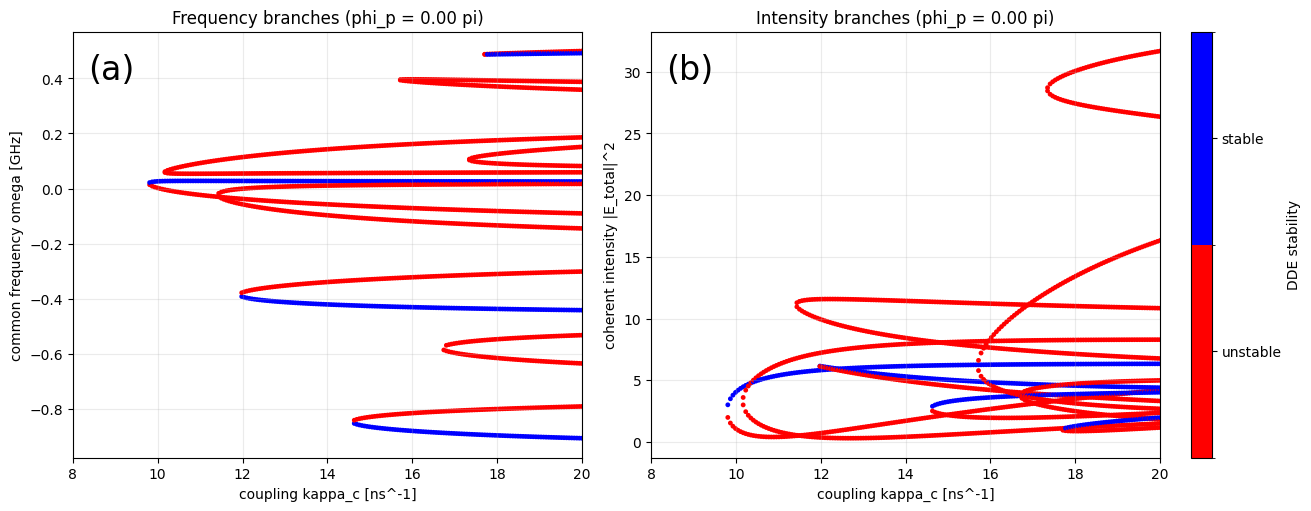

In [4]:
kappa_plot = []
omega_plot = []
intensity_plot = []
stability_plot = []

for kappa_c, eqs, stability in zip(kappa_values, all_equilibria, all_stability):
    if len(eqs) == 0:
        continue
    photon_numbers = eqs[:, 1::2][:, :N_lasers]
    omega = eqs[:, -1]
    phase = np.column_stack((np.zeros(len(eqs)), eqs[:, 2 * N_lasers:3 * N_lasers - 1]))
    fields = np.sqrt(photon_numbers) * np.exp(1j * (phase + omega[:, None] * tau))

    kappa_plot.extend(np.full(len(eqs), kappa_c * 1e-9))
    omega_plot.extend(omega / (2 * np.pi * tau_p) * 1e-9)
    intensity_plot.extend(np.abs(np.sum(fields, axis=1)) ** 2)
    stability_plot.extend(stability)

kappa_plot = np.asarray(kappa_plot)
omega_plot = np.asarray(omega_plot)
intensity_plot = np.asarray(intensity_plot)
stability_plot = np.asarray(stability_plot)

if kappa_plot.size == 0:
    raise RuntimeError('No equilibria were found. Increase the seed grid or adjust the sweep range.')

print(f'Plotting {len(kappa_plot)} equilibrium points.')

cmap = ListedColormap(['red', 'blue'])
norm = BoundaryNorm([-0.5, 0.5, 1.5], cmap.N)
colors = np.where(stability_plot == 1.0, 'blue', 'red') if calculate_stability else 'black'

fig, axes = plt.subplots(1, 2, figsize=(13, 5), constrained_layout=True)
axes[0].scatter(kappa_plot, omega_plot, c=colors, s=12, linewidths=0)
axes[0].set(title=f'Frequency branches (phi_p = {phi_p / np.pi:.2f} pi)',
            xlabel='coupling kappa_c [ns^-1]', ylabel='common frequency omega [GHz]')

axes[1].scatter(kappa_plot, intensity_plot, c=colors, s=12, linewidths=0)
axes[1].set(title=f'Intensity branches (phi_p = {phi_p / np.pi:.2f} pi)',
            xlabel='coupling kappa_c [ns^-1]', ylabel='coherent intensity |E_total|^2')
for ax, label in zip(axes, ['(a)', '(b)']):
    ax.set_xlim(kappa_values[0] * 1e-9, kappa_values[-1] * 1e-9)
    ax.text(0.03, 0.95, label, transform=ax.transAxes, va='top', fontsize=24)
    ax.grid(alpha=0.25)
if calculate_stability:
    colorbar = fig.colorbar(
        plt.cm.ScalarMappable(cmap=cmap, norm=norm), ax=axes, ticks=[0, 1], pad=0.02
    )
    colorbar.ax.set_yticklabels(['unstable', 'stable'])
    colorbar.set_label('DDE stability')


plt.show()

## 6. Three-dimensional branch view

This combines the preceding panels: coupling on x, common frequency on y, and coherent intensity on z. Rotate the plot interactively in a notebook backend, or change `view_init` to choose a different fixed camera angle.

In [5]:
import plotly.graph_objects as go

fig = go.Figure(
    data=go.Scatter3d(
        x=kappa_plot,
        y=omega_plot,
        z=intensity_plot,
        mode='markers',
        marker=dict(
            size=3,
            color=colors,
            opacity=0.8,
        ),
        customdata=np.column_stack((stability_plot,)),
        hovertemplate=(
            'Coupling: %{x:.3f} ns⁻¹<br>'
            'Frequency: %{y:.3f} GHz<br>'
            'Intensity: %{z:.3f}<br>'
            'Stable: %{customdata[0]}'
            '<extra></extra>'
        ),
    )
)

fig.update_layout(
    title='Equilibrium branches',
    scene=dict(
        aspectmode='cube',
        xaxis=dict(
            title='coupling kappa_c [ns⁻¹]',
            range=[kappa_values[0] * 1e-9, kappa_values[-1] * 1e-9],
        ),
        yaxis_title='common frequency omega [GHz]',
        zaxis_title='coherent intensity |E_total|²',
    ),
    width=900,
    height=700,
)

fig.show()

## 7. Time-domain check at the slide-7 target

This optional single simulation uses the slide-8 matrices at the `vcsel_lib` budget equivalent to the collaborator's $5.62\,\mathrm{ns}^{-1}$: $9.7341\,\mathrm{ns}^{-1}$. It follows `simple_example.py`: start from a free-running history, ramp the coupling smoothly, and integrate the delayed system. A flat late-time photon-number trace is evidence that this trajectory has settled; it is not a replacement for the DDE eigenvalue stability calculation in the sweep below.

Integrating: 100%|██████████| 92222/92222 [00:09<00:00, 9691.85it/s] 


Final coupling budget: 14.0000 ns^-1
Late-time photon-number mean: [4.24013645 3.96962074 3.90181809]
Late-time photon-number standard deviation: [0.19636037 0.04081402 0.11988608]


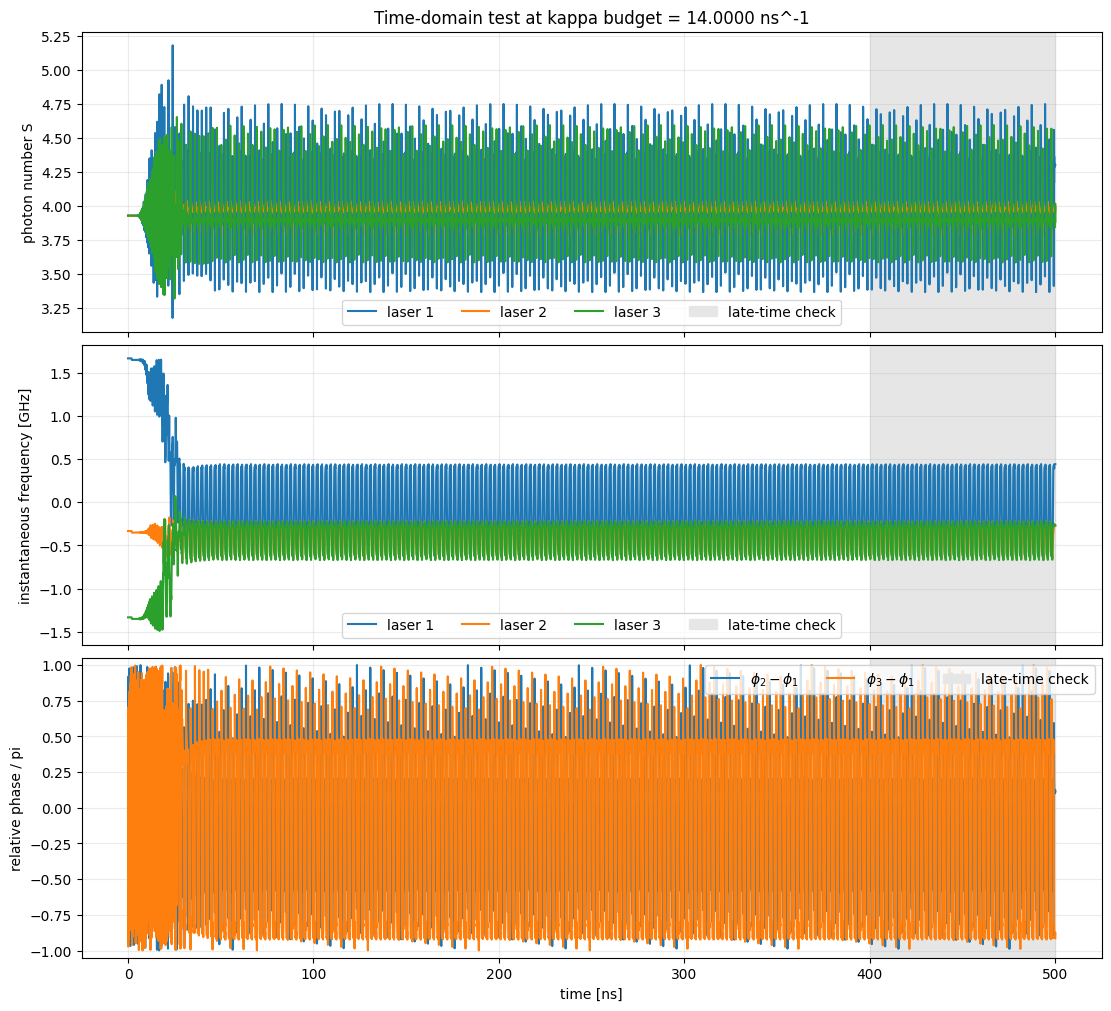

In [6]:
# This cell is independent of the equilibrium sweep above.
sim_kappa_budget = 14.0 * 1e9  # 9.7341 ns^-1 in vcsel_lib's sum-normalized convention
sim_dt = tau_p
sim_Tmax = 500e-9
sim_steps = int(np.round(sim_Tmax / sim_dt)) + 1
sim_time_arr = np.arange(sim_steps, dtype=float) * sim_dt
sim_Tmax = sim_time_arr[-1]

# Use the same smooth coupling ramp and free-running history as simple_example.py.
sim_kappa_arr = VCSEL.build_coupling_matrix(
    time_arr=sim_time_arr,
    kappa_initial=0.0,
    kappa_final=sim_kappa_budget,
    N_lasers=N_lasers,
    ramp_start=5.0,
    ramp_shape=10.0,
    tau=tau,
    scheme='CUSTOM',
    aMAT=aMAT,
    plot=False,
)
assert np.isclose(sim_kappa_arr[-1].sum(), sim_kappa_budget)

phys_sim = phys.copy()
phys_sim.update({
    'kappa_c_mat': sim_kappa_arr,
    'phi_p_mat': phys['phi_p_mat'],  # slide 8 coupling phases
    'dt': sim_dt,
    'Tmax': sim_Tmax,
    'save_every': 10,
    'noise_amplitude': 0.0,
})

sim_vcsel = VCSEL(phys_sim)
sim_nd = sim_vcsel.scale_params()
sim_history, sim_freq_hist, _, _ = sim_vcsel.generate_history(sim_nd, shape='FR', n_cases=1)
sim_t, sim_y, sim_freqs = sim_vcsel.integrate(
    sim_history, nd=sim_nd, progress=True, max_iter=1, smooth_freqs=True
)

sim_S = sim_y[0, 1::3, :]
sim_phase = sim_y[0, 2::3, :]

# Follow simple_example.py: convert phase derivatives to GHz, then restore
# the free-running frequency history over the initial delay interval.
sim_frequency_ghz = sim_freqs[0] * 1e-9 / (2 * np.pi * tau_p)
sim_save_every = int(max(1, sim_nd.get('save_every', 1)))
sim_freq_hist_plot = sim_freq_hist[0, :, ::sim_save_every]
sim_history_length = min(sim_freq_hist_plot.shape[1], sim_frequency_ghz.shape[1])
sim_frequency_ghz[:, :sim_history_length] = sim_freq_hist_plot[:, :sim_history_length]

# Absolute phases rotate continuously. Relative phases expose locking.
sim_relative_phase = np.angle(np.exp(1j * (sim_phase[1:] - sim_phase[0])))

late_start = int(0.8 * sim_S.shape[1])
late_mean = sim_S[:, late_start:].mean(axis=1)
late_std = sim_S[:, late_start:].std(axis=1)
print(f'Final coupling budget: {sim_kappa_arr[-1].sum() * 1e-9:.4f} ns^-1')
print('Late-time photon-number mean:', late_mean)
print('Late-time photon-number standard deviation:', late_std)

fig, axes = plt.subplots(3, 1, figsize=(11, 10), sharex=True, constrained_layout=True)
for laser_index, intensity in enumerate(sim_S, start=1):
    axes[0].plot(sim_t * 1e9, intensity, label=f'laser {laser_index}')
    axes[1].plot(sim_t * 1e9, sim_frequency_ghz[laser_index - 1], label=f'laser {laser_index}')
for laser_index, relative_phase in enumerate(sim_relative_phase, start=2):
    axes[2].plot(sim_t * 1e9, relative_phase / np.pi, label=rf'$\phi_{{{laser_index}}}-\phi_1$')

for ax in axes:
    ax.axvspan(sim_t[late_start] * 1e9, sim_t[-1] * 1e9, color='0.9', label='late-time check')
    ax.grid(alpha=0.25)
axes[0].set(title=f'Time-domain test at kappa budget = {sim_kappa_budget * 1e-9:.4f} ns^-1', ylabel='photon number S')
axes[1].set(ylabel='instantaneous frequency [GHz]')
axes[2].set(xlabel='time [ns]', ylabel='relative phase / pi', ylim=(-1.05, 1.05))
axes[0].legend(ncol=N_lasers + 1)
axes[1].legend(ncol=N_lasers + 1)
axes[2].legend(ncol=N_lasers)
plt.show()